## **Análisis de Señales EEG para la Identificación de Patrones en Tareas de Imaginación Motora**

Pamela Huacca Arce | Paula Andrea Cataño Cano

### **1. Introducción**

El desarrollo de las Interfaces Cerebro-Computador (BCI) representa un desafío ambicioso en la ingeniería contemporánea, al establecer un canal directo de comunicación entre el cerebro y dispositivos externos sin depender de las vías neuromusculares tradicionales. El presente trabajo se enmarca en la evaluación de la factibilidad de sistemas BCI no invasivos, utilizando señales de electroencefalografía (EEG) para diferenciar estados de reposo, movimiento real y, fundamentalmente, imaginación motora (Motor Imagery).  

A través del uso de herramientas integradas en Python, este proyecto busca implementar un flujo de procesamiento que permita la manipulación de bioseñales, la aplicación de algoritmos de procesamiento y el análisis de la densidad espectral de potencia (PSD) para realizar inferencias estadísticas sobre los ritmos cerebrales asociados al control motor.


### **2. Marco Teórico y Estado del Arte**

**2.1 Evolución y Perspectivas de las Interfaces Cerebro-Computador (BCI)**

La interacción entre señales eléctricas y funciones biológicas ha recorrido un camino extenso desde los registros de Luigi Galvani en 1771 y Richard Caton en 1875, quienes sentaron las bases de la bioelectricidad. Sin embargo, el hito fundamental para este proyecto ocurre en 1924, cuando Hans Berger registra el primer EEG humano, identificando los ritmos alfa y beta. Este descubrimiento fue perfeccionado por Herbert Jasper, quien estandarizó la colocación de electrodos para optimizar el procesamiento de señales en tiempo real. Finalmente, en 1948, William Grey Walter desarrolló la Machina Speculatrix, uno de los primeros sistemas capaces de establecer una comunicación básica entre el cerebro y un dispositivo externo.  

En la actualidad, las BCI han pasado de ser experimentos de laboratorio a herramientas clínicas para la neurorrehabilitación post-ictus y el control de prótesis, así como aplicaciones en el entretenimiento mediante dispositivos portátiles y no invasivos. El futuro de esta tecnología apunta hacia sistemas de "circuito cerrado" y neuro-aumentación, integrando bioseñales con entornos de realidad virtual y aumentada.   

**2.2 Fundamentos Neurofisiológicos del Movimiento**

Para el análisis de tareas de movimiento (MM) e imaginación motora (MI), es crucial identificar la actividad en la corteza motora. Según el sistema internacional 10-20, los electrodos de mayor relevancia son **C3** (hemisferio izquierdo, asociado a la mano derecha), **C4** (hemisferio derecho, asociado a la mano izquierda) y **Cz** (línea media).  

La discriminación entre condiciones se basa en dos fenómenos espectrales:
- **Ritmo Mu (8-13 Hz):** Presenta una Desincronización Relacionada con Eventos (ERD), traduciéndose en una caída de potencia cuando el sujeto ejecuta o imagina un movimiento.   
- **Ritmo Beta (13-30 Hz):** Relacionado con la alerta motora y caracterizado por un "rebote" de potencia tras finalizar la tarea.   

Investigaciones previas indican que  es posible predecir rangos de frecuencia específicos para MI en los electrodos C3 y C4 que oscilan entre los 8 y 26 Hz, permitiendo así una diferenciación matemática del estado de reposo. Para efectos de este trabajo se analizarán también los electrodos con una cercanía a los electrodos de interés reportados en la litaratura, con el fin de terner información de la mayor parte de la cprteza mototra y extraer inofrmación significante de cada caso. (C1, C2, CP1, CP2, FC1, FC2, C4, C5).

![corteza motora](image.png)


### **3. Planteamineto de hipótesis**

**3.1 Comparación Reposo vs. Imaginería (Focalizada en ritmo Mu)**
- Hipótesis Nula ($H_0$): No existen diferencias significativas en la densidad espectral de potencia (PSD) de la banda Mu (8-13 Hz) entre el estado de reposo (CE/OE) y la tarea de imaginería motora.
- Hipótesis Alternativa ($H_1$): La potencia en la banda Mu disminuye significativamente (ERD) durante la imaginería motora en comparación con el estado de reposo.

**3.2 Comparación Imaginería vs. Movimiento Real (Similitud funcional)**
- Hipótesis Nula ($H_0$): No existen diferencias significativas en la distribución topográfica y espectral de la señal de EEG entre la ejecución del movimiento real y la imaginación del mismo.
- Hipótesis Alternativa ($H_1$): Existen diferencias significativas en la magnitud de la potencia espectral entre el movimiento real y la imaginería, aunque compartan la misma localización espacial (corteza motora).

### **4. Flujo de Procesamiento Propuesto**
Para cumplir con el pbejtivo de análisis, el flujo de procesamiento debe seguir estos pasos lógicos:


1. Carga y Limpieza: Importar los datos y aplicar filtros lineales (paso de banda, detrend) para eliminar tendencias lineales provocadas por los cambios en la impedancia, ruidos de baja frecuencia y ruido muscular.

- Se implementará un filtro pasabanda FIR  con frecuencias de corte entre 8 Hz y 30 Hz. Este rango permite aislar los ritmos Mu (8-13 Hz) y Beta (13-30 Hz), eliminando ruidos de alta frecuencia y artefactos no biológicos.

2. Segmentación (Epoching): Segmentación (Epoching): La señal continua se dividirá en épocas utilizando los marcadores de eventos del dataset. Se extraerán segmentos correspondientes a las cuatro condiciones: movimiento mano derecha/izquierda e imaginación mano derecha/izquierda, además de los periodos de reposo.

4.  Extracción de Características (PSD): Se calculará la Densidad Espectral de Potencia (PSD) mediante el método de Welch. Esta técnica permitirá promediar el periodograma para obtener una estimación robusta de la potencia en las bandas de interés, facilitando la comparación entre las condiciones de tarea y reposo.

5. Análisis de pruebas estadísticas: Se evaluará la normalidad de la distribución de la potencia mediante pruebas como Shapiro-Wilk. En caso de normalidad, se emplearán pruebas paramétricas (t-student); de lo contrario, se utilizarán pruebas no paramétricas (man- whitney) para comparar las medias de potencia entre las condiciones.

6. Representación de Resultados: Se utilizarán Boxplots (diagramas de caja) para describir la dispersión de la potencia y facilitar la identificación de diferencias estadísticas significativas entre las cuatro tareas y el reposo.



In [2]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import welch as pwelch
from scipy import stats
import pandas as pd
import scipy.io as sio
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

### **Verificación del Dataset**  

In [12]:
import glob

ruta = r'D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files'

carpetas_sujetos = glob.glob(os.path.join(ruta, "S*"))

print("REPORTE DE DATASET - EEG MOTOR MOVEMENT IMAGERY DATASET")
print(f"Total de sujetos encontrados: {len(carpetas_sujetos)-1}") # -1 para excluir el "SHA256SHUM.txt"

archivos_edf = glob.glob(os.path.join(carpetas_sujetos[0], "*.edf"))
print(f"Archivos .edf encontrados en el sujeto 1: {len(archivos_edf)}")
    

REPORTE DE DATASET - EEG MOTOR MOVEMENT IMAGERY DATASET
Total de sujetos encontrados: 109
Archivos .edf encontrados en el sujeto 1: 14


### **Carga y selección de canales- prueba SUJETO 01**

In [104]:
ruta_S1 = r"D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files\S001\S001R04.edf" 
raw = mne.io.read_raw_edf(ruta_S1, preload=True, verbose=False)
raw.rename_channels(lambda x: x.strip('.')) # Para eliminar los puntos al final de los nombres de los canales
raw

# Yo dejaría la impresión del RAW para la ahí se muestra toa la info que tienes acá abajo

# print("-----EXPLORACIÓN DEL ARCHIVO EEG ----")
# print(f"Frecuencia de muestreo (Fs): {raw.info['sfreq']} Hz")
# print(f"Duración total del registro: {raw.times[-1]:.2f} segundos")
# print(f"Número total de canales: {len(raw.ch_names)}")
# print(f"Canales: {raw.ch_names} ...")

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

(64, 20000)


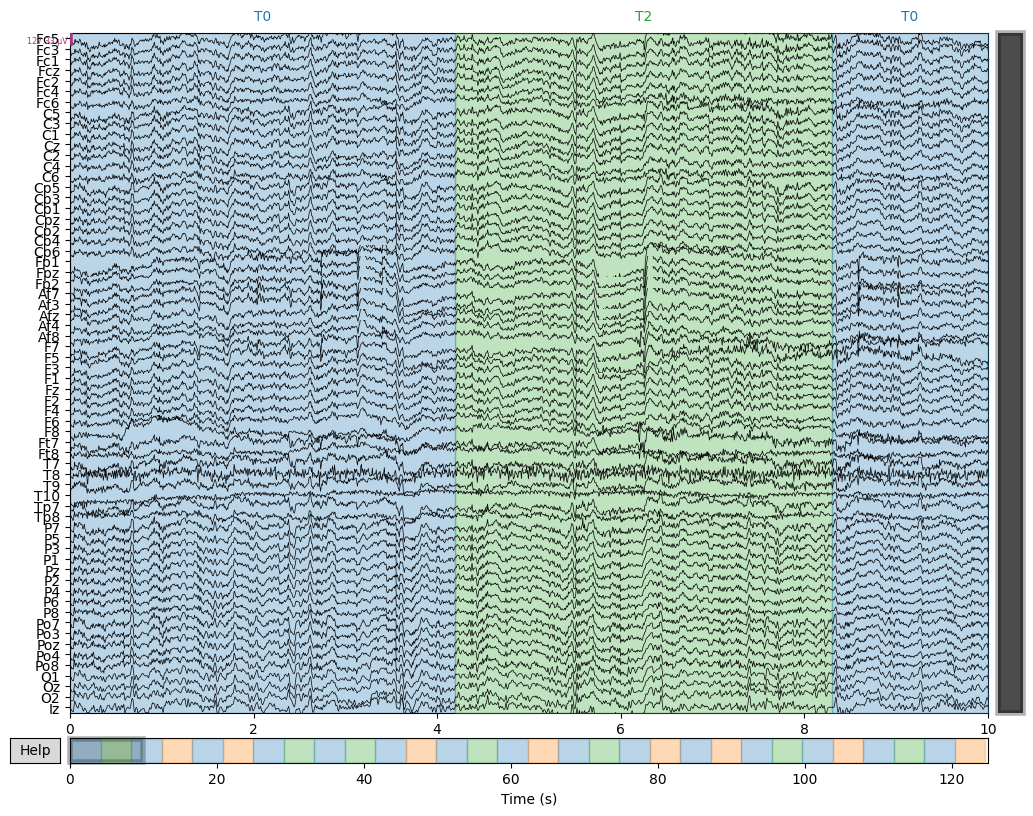

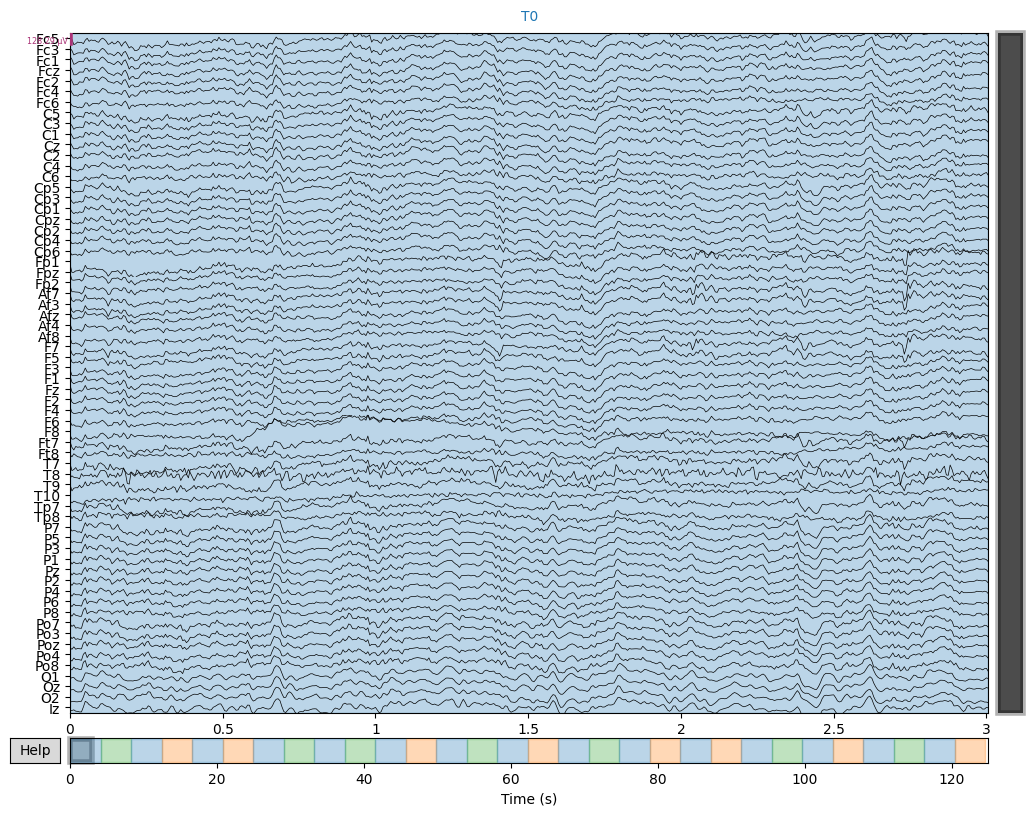

In [105]:
# INSPECCIÓN VISUAL 1: Señal cruda
data = raw.get_data()
print(data.shape)
raw.plot(n_channels=64, scalings='auto');
raw.plot(n_channels=64, duration=3.0, scalings='auto');

Para el análisis del efecto del proceso de filtrado en la señal se seleccionan tres canales aleatorios (C3, Fp1 y Po7), esto únicamente para que la visualización sea más simple.

In [106]:
raw.pick_channels(['C3', 'Fp1', 'Po7'])
datos = raw.get_data()

print(f"\nTamaño de la nueva matriz de datos: {datos.shape}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

Tamaño de la nueva matriz de datos: (3, 20000)


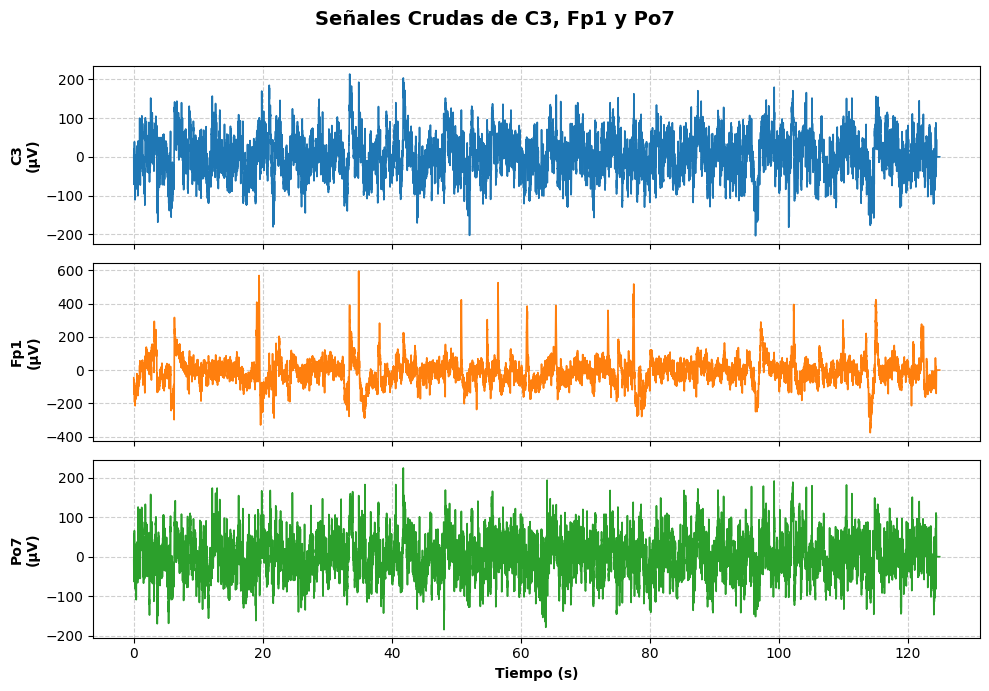

In [107]:
# GRPAFICA DE ESTOS TRES CANALES - SEÑAL CRUDA

datos_ = datos * 1e6
Fs = int(raw.info['sfreq'])
T = np.arange(datos_.shape[1]) / Fs

lim = datos_.shape[1]
T_plot = T[:lim]


fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Señales Crudas de C3, Fp1 y Po7", fontsize=14, fontweight='bold')
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, canal in enumerate(raw.ch_names):
    axs[i].plot(T_plot, datos_[i, :lim], color=colores[i], linewidth=1.2)
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

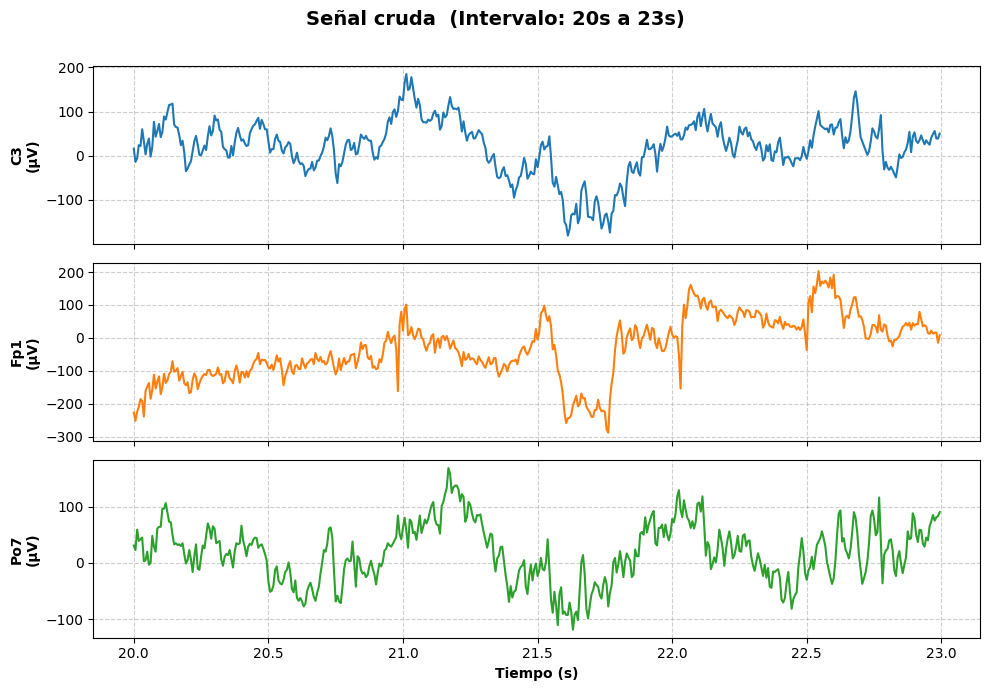

In [108]:
inicio_seg = 20 
fin_seg = 23     


idx_inicio = int(20 * Fs)
idx_fin = int(23 * Fs)
T_lim = T[idx_inicio:idx_fin]

# graficamos
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f"Señal cruda  (Intervalo: {inicio_seg}s a {fin_seg}s)", fontsize=14, fontweight='bold')
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, canal in enumerate(raw.ch_names):
    # Graficamos recortando también los datos en el mismo intervalo (idx_inicio a idx_fin)
    axs[i].plot(T_lim, datos_[i, idx_inicio:idx_fin], color=colores[i], linewidth=1.5)
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle='--', alpha=0.6)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## **Proceso de Filtrado**

### **1. Detrend:**
Este filtro permitirá eliminar tendencias lineales, generalmante de bajas frecuencias. El tipo de ruido que elimina puede ser derivado de los cambios de la impedancia a lo largo del registro ocacionados por sudoración del participante, entre otros ruidos de baja frecuencia

In [109]:
from scipy.signal import detrend

raw_detrend = raw.copy() 
# Para aplicar el detrend solo a los canales EEG, usamos picks
picks_eeg = mne.pick_types(raw_detrend.info, eeg=True, exclude='bads')

# Usamos channel_wise=True porque el detrend lineal se calcula por electrodo
raw_detrend.apply_function(detrend, picks=picks_eeg, channel_wise=True)

# Data en µV
datos_detrend = raw_detrend.get_data(picks=picks_eeg) * 1e6


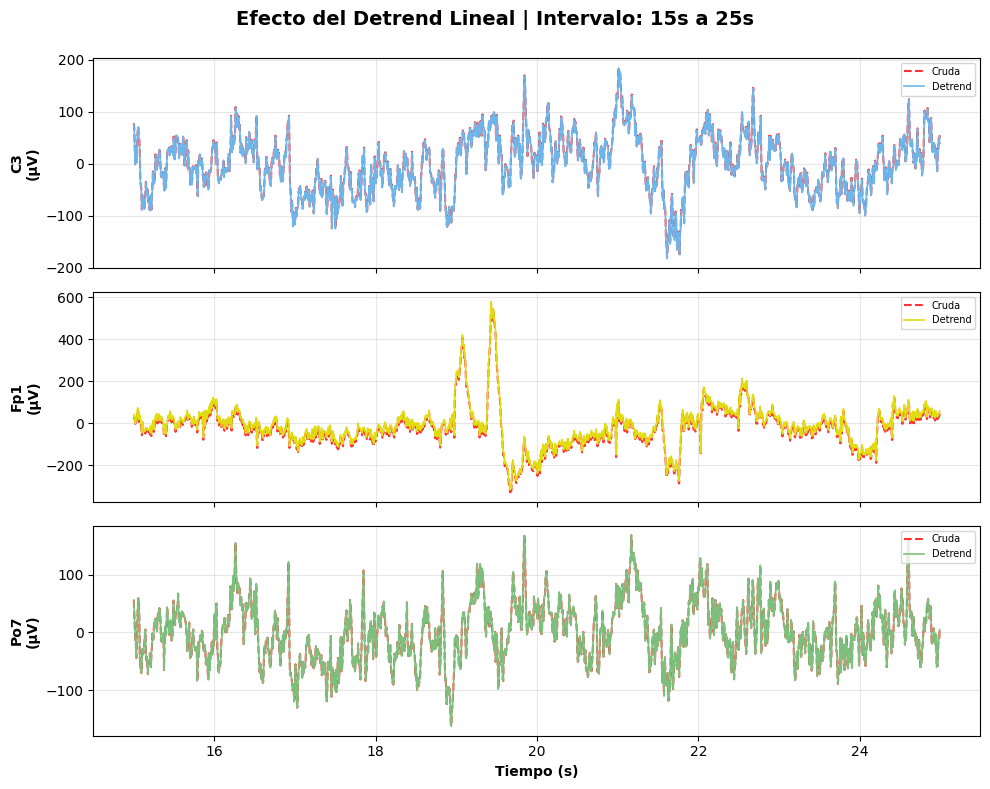

In [117]:
# GRÁFICA COMPARATIVA: SEÑAL CRUDA VS DETREND
inicio_seg = 15
fin_seg = 25

idx_inicio = int(inicio_seg * Fs)
idx_fin = int(fin_seg * Fs)

T_lim = T[idx_inicio:idx_fin]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f"Efecto del Detrend Lineal | Intervalo: {inicio_seg}s a {fin_seg}s",
             fontsize=14, fontweight='bold')

for i, canal in enumerate(raw_detrend.ch_names):
    axs[i].plot(T_lim, datos_[i, idx_inicio:idx_fin],
                color='red', linestyle='--', alpha=0.8, label='Cruda')
    
    colores = ["#6eb6ea", "#e0dc10", "#7dc07d"]
    axs[i].plot(T_lim, datos_detrend[i, idx_inicio:idx_fin],
                color=colores[i], linewidth=1.2, label='Detrend')
    
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend(loc='upper right', fontsize=7)

axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

No se observa un cambio en la señal al aplicar un filtro Detrend a la señal, por tanto este filtro se descarta para el procesamiento general de los datos.

### **Pasabandas FIR 8-30 Hz:**
Para el filtrado de paso de banda se selecciona una fracuencia de corte entra 8 y 30 Hz, esta desición se toma según literatura, teniendo en cuenta la frecuencias de interés en el análisis de tareas de imaginería (ritmos Mu y Beta). 

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



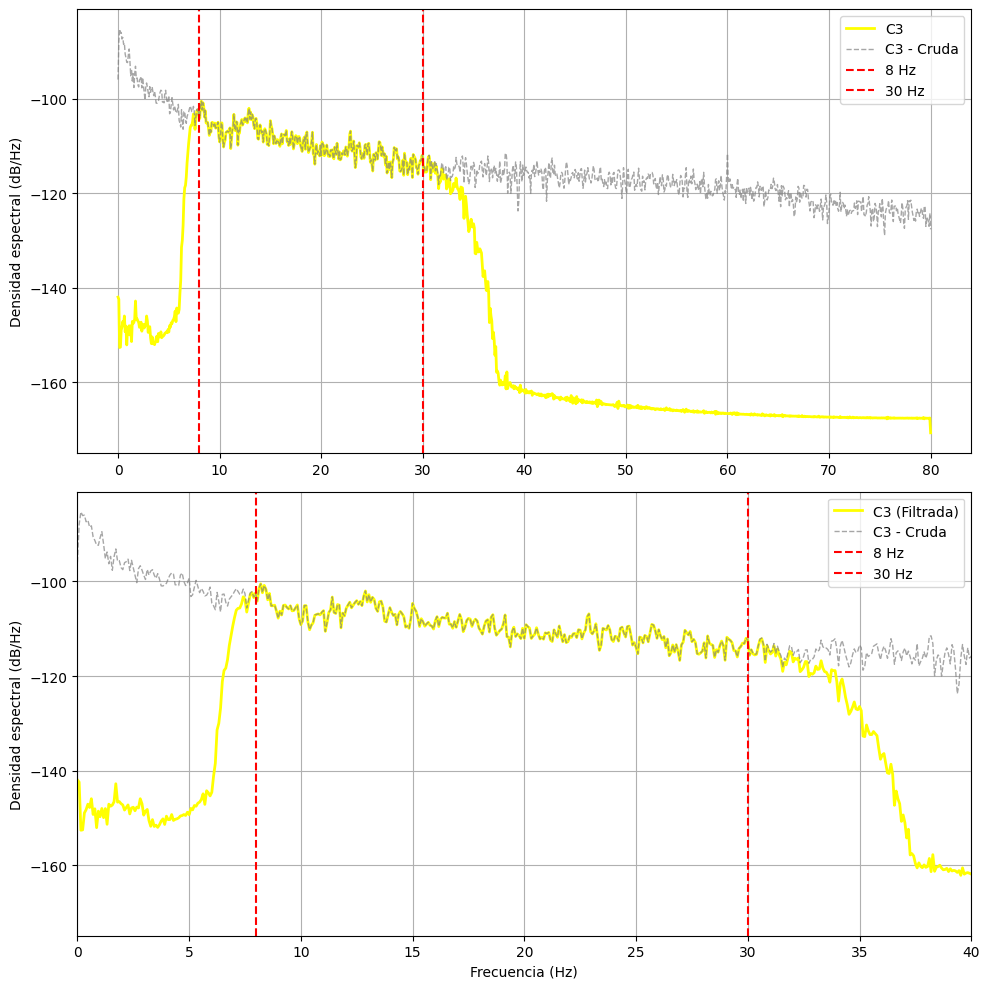

In [165]:
# FILTRADO PASABANDA (8-30 Hz)

# CASO 1

raw_filtrado = raw.copy() 

# Identificamos solo los canales EEG (como hace el profe en sus notebooks)
picks_eeg = mne.pick_types(raw_filtrado.info, eeg=True)
bandpass = raw_filtrado.filter(8.0, 30.0, picks=picks_eeg, 
                    method='fir', fir_design='firwin')

#PSD del canal C3 para visualizar el efecto del filtro en el dominio de la frecuencia
psd = bandpass.compute_psd(method='welch', picks='C3', verbose=False)
psd_canal = psd.get_data(picks='C3').flatten()
freqs = psd.freqs

psd_ = raw.compute_psd(method='welch', picks='C3', verbose=False)
psd_canal_ = psd_.get_data(picks='C3').flatten()
freqs_ = psd_.freqs

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(freqs, 10 * np.log10(psd_canal), label='C3', color = 'yellow', linewidth=2)
plt.plot(freqs_, 10 * np.log10(psd_canal_),
        color='gray', linestyle='--', alpha=0.7, linewidth=1,label='C3 - Cruda')
plt.axvline(8, color='r', linestyle='--', label='8 Hz')
plt.axvline(30, color='r', linestyle='--', label='30 Hz')
plt.ylabel('Densidad espectral (dB/Hz)')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(freqs, 10 * np.log10(psd_canal), label='C3 (Filtrada)', color='yellow', linewidth=2)
plt.plot(freqs_, 10 * np.log10(psd_canal_), color='gray', linestyle='--', alpha=0.7, linewidth=1, label='C3 - Cruda')
plt.axvline(8, color='r', linestyle='--', label='8 Hz')
plt.axvline(30, color='r', linestyle='--', label='30 Hz')
plt.xlim(0, 40) 
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral (dB/Hz)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8.5 - 28 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.50
- Lower transition bandwidth: 2.12 Hz (-6 dB cutoff frequency: 7.44 Hz)
- Upper passband edge: 28.50 Hz
- Upper transition bandwidth: 7.12 Hz (-6 dB cutoff frequency: 32.06 Hz)
- Filter length: 249 samples (1.556 s)



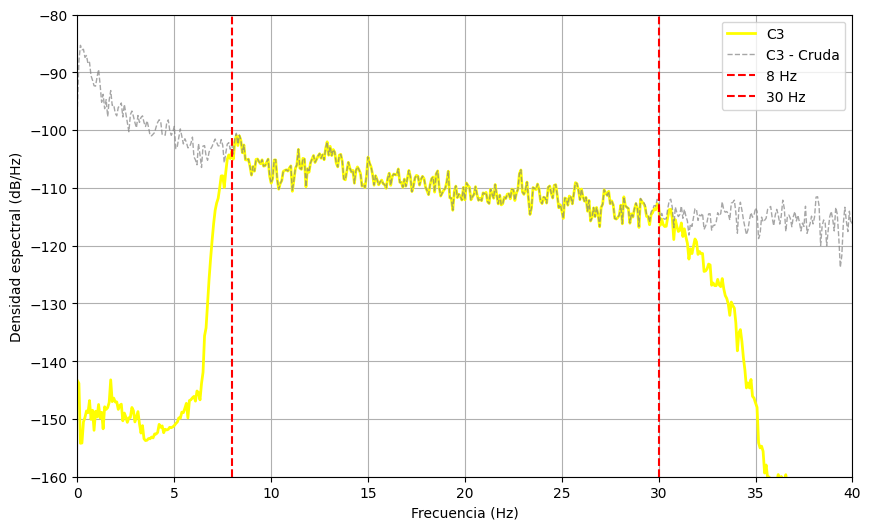

In [166]:
raw_filtrado2 = raw.copy() 

# Identificamos solo los canales EEG (como hace el profe en sus notebooks)
picks_eeg = mne.pick_types(raw_filtrado2.info, eeg=True)
bandpass = raw_filtrado2.filter(8.5, 28.5, picks=picks_eeg, 
                    method='fir', fir_design='firwin')

#PSD del canal C3 para visualizar el efecto del filtro en el dominio de la frecuencia
psd = bandpass.compute_psd(method='welch', picks='C3', verbose=False)
psd_canal = psd.get_data(picks='C3').flatten()
freqs = psd.freqs

psd_ = raw.compute_psd(method='welch', picks='C3', verbose=False)
psd_canal_ = psd_.get_data(picks='C3').flatten()
freqs_ = psd_.freqs

plt.figure(figsize=(10, 6))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral (dB/Hz)')
plt.plot(freqs, 10 * np.log10(psd_canal), label='C3', color = 'yellow', linewidth=2)
plt.plot(freqs_, 10 * np.log10(psd_canal_),
        color='gray', linestyle='--', alpha=0.7, linewidth=1,label='C3 - Cruda')
plt.axvline(8, color='r', linestyle='--', label='8 Hz')
plt.axvline(30, color='r', linestyle='--', label='30 Hz')
plt.xlim(0, 40)
plt.ylim(-160, -80)
plt.grid()
plt.legend()

plt.show()

Se opta por realizar definir la frecuencia de corte del filtro en 8.5 y 28.5 Hz. Como se puede observar en el diagraa del segundo espectro, este converva la señal en la bandas de interés para el problema, sin que deje pasar tanta información por fuera de la banda como se evidencia en el caso 1.

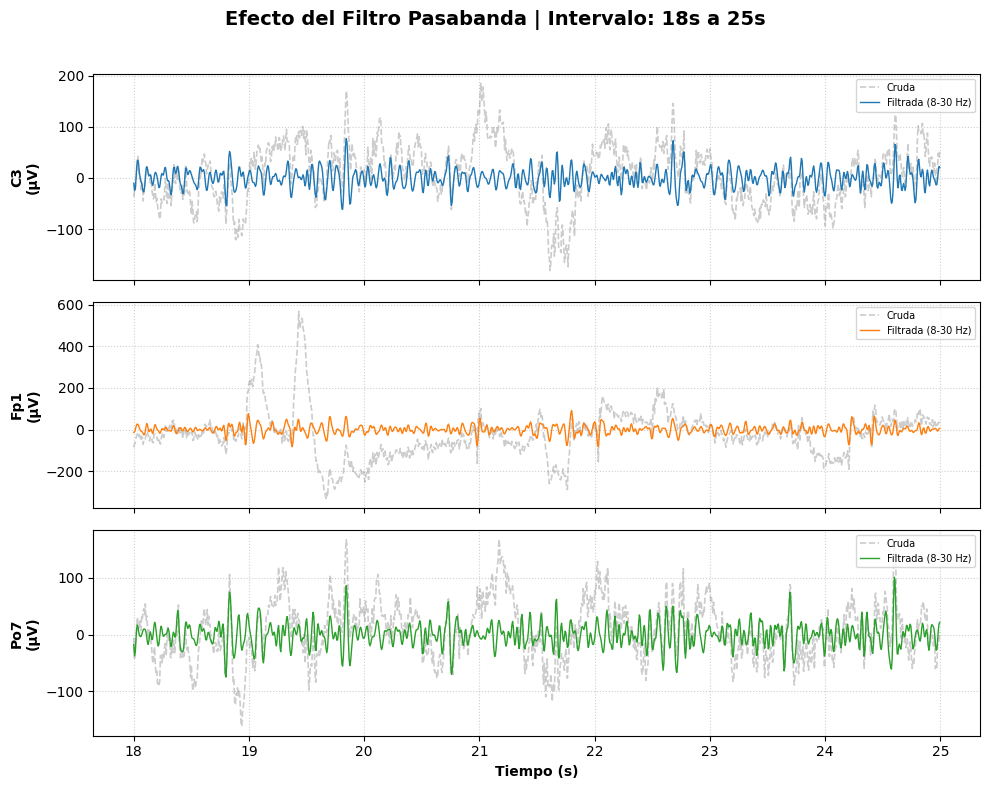

In [171]:
# GRÁFICA COMPARATIVA: SEÑAL CRUDA VS PASABANDA (8-30 Hz)

inicio_seg = 18
fin_seg = 25

idx_inicio = int(inicio_seg * Fs)
idx_fin = int(fin_seg * Fs)

T_lim = T[idx_inicio:idx_fin]

# Datos limpios en µV
datos_bandpass = bandpass.get_data(picks=picks_eeg) * 1e6

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f"Efecto del Filtro Pasabanda | Intervalo: {inicio_seg}s a {fin_seg}s", 
             fontsize=14, fontweight='bold')



# Iteramos por cada uno de los 3 canales
for i, canal in enumerate(raw_filtrado2.ch_names): 
    axs[i].plot(T_lim, datos_[i, idx_inicio:idx_fin], 
                color='gray', linestyle='--', alpha=0.4, linewidth=1.2, label='Cruda')
    
    color = ['#1f77b4', '#ff7f0e', '#2ca02c']
    axs[i].plot(T_lim, datos_bandpass[i, idx_inicio:idx_fin], 
                color=color[i], linewidth=1, label='Filtrada (8-30 Hz)')
    
    axs[i].set_ylabel(f"{canal}\n(µV)", fontweight='bold')
    axs[i].grid(True, linestyle=':', alpha=0.6)
    axs[i].legend(loc='upper right', fontsize=7)


axs[-1].set_xlabel("Tiempo (s)", fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.90) # Ajuste extra para el título
plt.show()

## **Segmentación-epoching**

In [184]:
# Extraemos los eventos de la señal filtrada  (FIR)
eventos, eventos_id = mne.events_from_annotations(raw_filtrado2)

print("--- DICCIONARIO DE EVENTOS ENCONTRADO ---")
print(eventos_id)
print("\n--- ETIQUETAS ÚNICAS ---")
print(np.unique(raw_filtrado2.annotations.description))

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
--- DICCIONARIO DE EVENTOS ENCONTRADO ---
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

--- ETIQUETAS ÚNICAS ---
['T0' 'T1' 'T2']


In [182]:
# SEGMENTACIÓN (EPOCHING)

print("====Segmentación por épocas====")

event_dict = {
    'Mano_Izquierda': 2, 
    'Mano_Derecha': 3,
    'Reposo': 1
}

# Ventana de tiempo (Metodología: -1s a 4s)
tmin = -1.0  # Un segundo antes de la marca
tmax = 4.0   # Cuatro segundos después de la marca

# Creamos las épocas
epochs = mne.Epochs(raw_filtrado2, eventos, event_id=event_dict, 
                    tmin=tmin, tmax=tmax, baseline=(None, 0), 
                    preload=True, verbose=False)

print(f"-> Épocas creadas exitosamente.")
print(f"Detalle: {epochs}")

====Segmentación por épocas====
-> Épocas creadas exitosamente.
Detalle: <Epochs | 29 events (all good), -1 – 4 s (baseline -1 – 0 s), ~552 KiB, data loaded,
 'Mano_Izquierda': 8
 'Mano_Derecha': 7
 'Reposo': 14>


## **welch**

In [191]:
# PSD por WELCH para estos tres canales

#print("Calculando la Densidad Espectral de Potencia (PSD) mediante Welch...")

# con el fmin y fmax definimos tu rango de interés de 8 a 30 Hz
#  con el n_fft=256 y n_overlap=128 se realiza un solapamiento del 25%

psd_obj = epochs.compute_psd(method='welch', fmin=8, fmax=30, 
                             n_fft=256, n_overlap=128, verbose=False)

# psds tiene forma: (n_épocas, n_canales, n_frecuencias)
psds, freqs = psd_obj.get_data(return_freqs=True)

psds_db = 10 * np.log10(psds)

#print(f"-> Características extraídas con éxito.")
print(f"Forma de la matriz de potencia: {psds.shape}")

Forma de la matriz de potencia: (29, 3, 36)


Effective window size : 1.600 (s)
Effective window size : 1.600 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


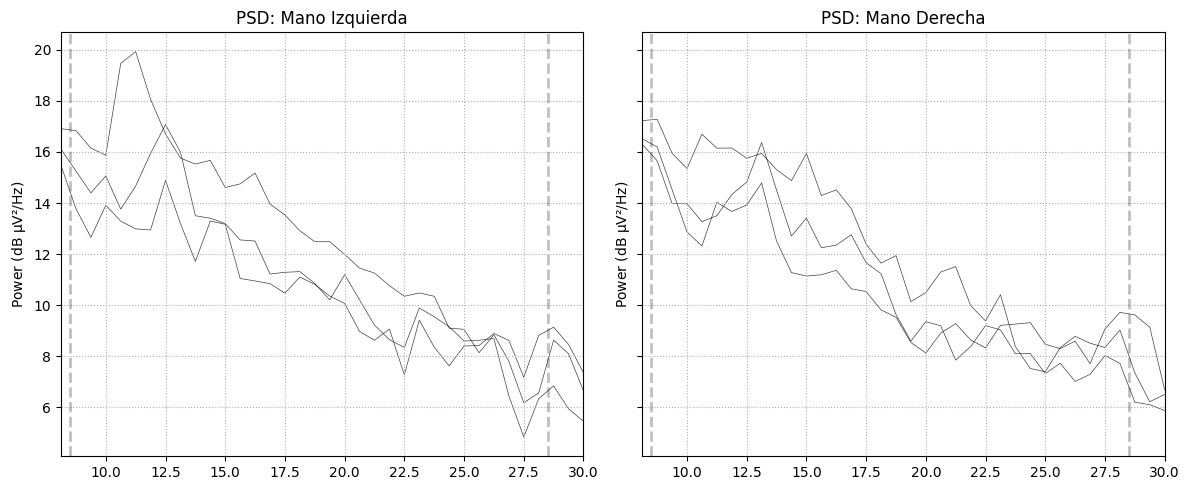

In [194]:
# Calculamos el PSD promedio por condición para visualizar

psd_izq = epochs['Mano_Izquierda'].compute_psd(method='welch', fmin=8, fmax=30, n_fft=256, n_overlap=128)
psd_der = epochs['Mano_Derecha'].compute_psd(method='welch', fmin=8, fmax=30, n_fft=256, n_overlap=128)

# Graficamos
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

psd_izq.plot(picks='eeg', axes=ax[0], show=False)
ax[0].set_title('PSD: Mano Izquierda')

psd_der.plot(picks='eeg', axes=ax[1], show=False)
ax[1].set_title('PSD: Mano Derecha')

plt.tight_layout()
plt.show()

In [210]:
base_path = r"D:\LabBiosenales\eeg-motor-movementimagery-dataset-1.0.0\files"
datos_psd = []

runs_dict = {
    'Reposo_OE': ['01'],
    'Reposo_CE': ['02'],
    'Movimiento': ['03', '07', '11'],
    'Imagineria': ['04', '08', '12']
}

print("Iniciando filtrado y extracción de Potencia Relativa para 109 sujetos en 64 canales...")

for i in range(1, 110):
    subject = f"S{i:03d}"
    
    for tarea, runs in runs_dict.items():
        for run in runs:
            file_name = f"{subject}R{run}.edf"
            file_path = os.path.join(base_path, subject, file_name)
            
            if not os.path.exists(file_path):
                continue
                
            # 1. Carga del archivo
            raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
            raw.rename_channels(lambda x: x.strip('.'))
            
            # 2. Filtro Pasabanda
            raw.filter(8.5, 28.5, picks=picks_eeg, method='fir', fir_design='firwin', verbose=False)
            
            # 3. Segmentación (Epoching) con Detrending (tendencia lineal)
            try:
                if tarea in ['Reposo_OE', 'Reposo_CE']:
                    # El reposo continuo lo dividimos en ventanas fijas de 2 segundos
                    epochs = mne.make_fixed_length_epochs(raw, duration=2.0, preload=True, verbose=False)
                    condiciones = {'T0': epochs} # T0 representará el reposo
                else:
                    events, event_id = mne.events_from_annotations(raw, verbose=False)
                    # detrend=1 elimina la tendencia lineal de la época
                    epochs_totales = mne.Epochs(raw, events, event_id, tmin=0, tmax=2.0, baseline=None, detrend=1, preload=True, verbose=False)
                    condiciones = {cond: epochs_totales[cond] for cond in event_id.keys()}
                
                # 4. Cálculo de PSD (Welch) y Potencia Relativa por condición
                for condicion, eps in condiciones.items(): 
                    
                    # Extraer PSD usando Welch
                    psd, freqs = eps.compute_psd(method='welch', fmin=8, fmax=30,n_fft=256, n_overlap=128, verbose=False).get_data(return_freqs=True)
                    
                    # psd tiene forma (n_epocas, n_canales, n_frecuencias)
                    # Promediamos las épocas para tener una firma general de esa corrida
                    psd_mean = np.mean(psd, axis=0) # Queda de forma (n_canales, n_frecuencias)
                    
                    # Calcular la POTENCIA TOTAL (Suma de todo el espectro por canal)
                    potencia_total = np.sum(psd_mean, axis=1)
                    
                    # Índices de las bandas
                    idx_mu = np.logical_and(freqs >= 8, freqs <= 13)
                    idx_beta = np.logical_and(freqs >= 13, freqs <= 30)
                    
                    # Calcular POTENCIA ABSOLUTA (Suma en la banda)
                    pot_abs_mu = np.sum(psd_mean[:, idx_mu], axis=1)
                    pot_abs_beta = np.sum(psd_mean[:, idx_beta], axis=1)
                    
                    # Calcular POTENCIA RELATIVA (Absoluta / Total)
                    pot_rel_mu = pot_abs_mu / potencia_total
                    pot_rel_beta = pot_abs_beta / potencia_total
                    
                    # 5. Guardar iterando sobre TODOS los canales
                    nombres_canales = raw.ch_names
                    for idx_ch, ch_name in enumerate(nombres_canales):
                        datos_psd.append({
                            'Sujeto': subject,
                            'Tarea': tarea,
                            'Condicion_Evento': condicion, # T0, T1 (Izquierda), T2 (Derecha)
                            'Canal': ch_name,
                            'Mu_Pot_Rel': pot_rel_mu[idx_ch],
                            'Beta_Pot_Rel': pot_rel_beta[idx_ch]
                        })
                        
            except Exception as e:
                pass # Ignorar archivos corruptos o sin eventos válidos

# Crear el DataFrame final
df_resultados = pd.DataFrame(datos_psd)
print("¡Extracción finalizada! Tamaño del dataset:", df_resultados.shape)
# df_resultados.to_csv("psd_relativa_todos_canales.csv", index=False)

Iniciando filtrado y extracción de Potencia Relativa para 109 sujetos en 64 canales...
¡Extracción finalizada! Tamaño del dataset: (139520, 6)


In [211]:
df_resultados

,Sujeto,Tarea,Condicion_Evento,Canal,Mu_Pot_Rel,Beta_Pot_Rel
0,S001,Reposo_OE,T0,Fc5,0.492842,0.507158
1,S001,Reposo_OE,T0,Fc3,0.553843,0.446157
2,S001,Reposo_OE,T0,Fc1,0.536995,0.463005
3,S001,Reposo_OE,T0,Fcz,0.523289,0.476711
4,S001,Reposo_OE,T0,Fc2,0.535238,0.464762
...,...,...,...,...,...,...
139515,S109,Imagineria,T2,Po8,0.264626,0.735374
139516,S109,Imagineria,T2,O1,0.263038,0.736962
139517,S109,Imagineria,T2,Oz,0.290512,0.709488
139518,S109,Imagineria,T2,O2,0.257617,0.742383


In [206]:
df_resultados # con el solapamiento del 50%

,Sujeto,Tarea,Condicion_Evento,Canal,Mu_Pot_Rel,Beta_Pot_Rel
0,S001,Reposo_OE,T0,Fc5,0.492842,0.507158
1,S001,Reposo_OE,T0,Fc3,0.553843,0.446157
2,S001,Reposo_OE,T0,Fc1,0.536995,0.463005
3,S001,Reposo_OE,T0,Fcz,0.523289,0.476711
4,S001,Reposo_OE,T0,Fc2,0.535238,0.464762
...,...,...,...,...,...,...
139515,S109,Imagineria,T2,Po8,0.264626,0.735374
139516,S109,Imagineria,T2,O1,0.263038,0.736962
139517,S109,Imagineria,T2,Oz,0.290512,0.709488
139518,S109,Imagineria,T2,O2,0.257617,0.742383


In [201]:
df_resultados
# esto fue sin el solapamiento

,Sujeto,Tarea,Condicion_Evento,Canal,Mu_Pot_Rel,Beta_Pot_Rel
0,S001,Reposo_OE,T0,Fc5,0.518711,0.516619
1,S001,Reposo_OE,T0,Fc3,0.577274,0.464324
2,S001,Reposo_OE,T0,Fc1,0.563784,0.479231
3,S001,Reposo_OE,T0,Fcz,0.560572,0.491583
4,S001,Reposo_OE,T0,Fc2,0.581148,0.476726
...,...,...,...,...,...,...
139515,S109,Imagineria,T2,Po8,0.270227,0.729773
139516,S109,Imagineria,T2,O1,0.262950,0.737050
139517,S109,Imagineria,T2,Oz,0.297644,0.702356
139518,S109,Imagineria,T2,O2,0.283822,0.716178


In [205]:
df_resultados.to_csv("psd_relativa_todos_canales.csv", index=False)

In [213]:
df_unico_run = df_resultados.drop_duplicates(
    subset=['Sujeto', 'Tarea', 'Condicion_Evento', 'Canal'], 
    keep='first')

In [214]:
conteo_verificacion = df_unico_run[df_unico_run['Canal'] == 'C3'].groupby(['Tarea', 'Condicion_Evento']).size()
print("Nuevo conteo por condición (debe ser 109 o cercano):")
print(conteo_verificacion)

Nuevo conteo por condición (debe ser 109 o cercano):
Tarea       Condicion_Evento
Imagineria  T0                  109
            T1                  109
            T2                  109
Movimiento  T0                  109
            T1                  109
            T2                  109
Reposo_CE   T0                  109
Reposo_OE   T0                  109
dtype: int64


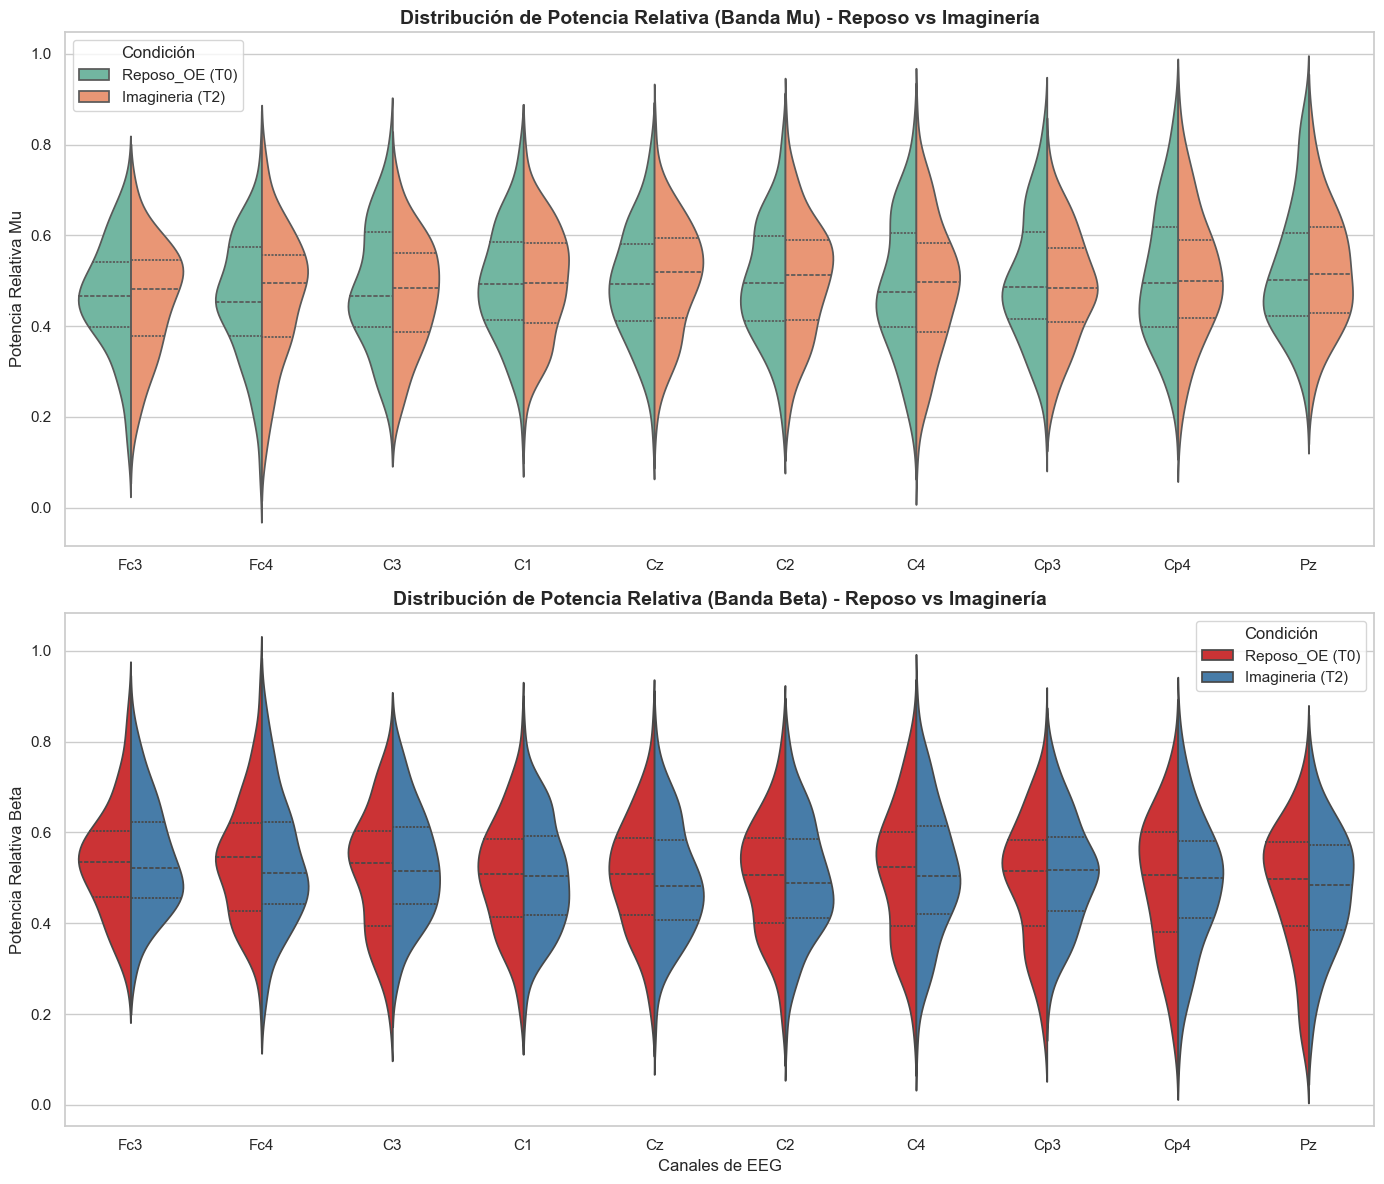

In [266]:
# 1. Definir los 10 canales clave enfocados en la corteza motora y áreas adyacentes
canales_plot = ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4', 'C1', 'C2', 'Pz']

# 2. Filtrar el DataFrame limpio (df_unico_run) para quedarnos solo con esos canales
df_plot = df_unico_run[df_unico_run['Canal'].isin(canales_plot)].copy()

# 3. Seleccionar las condiciones a comparar (Ejemplo: Reposo OE vs Imaginería Mano Derecha T2)
# Puedes cambiar esto a 'Movimiento' y 'Imagineria' según la hipótesis que estés discutiendo
tarea_1 = 'Reposo_OE'
cond_1 = 'T0'
tarea_2 = 'Imagineria'
cond_2 = 'T2'

df_filtrado = df_plot[
    ((df_plot['Tarea'] == tarea_1) & (df_plot['Condicion_Evento'] == cond_1)) |
    ((df_plot['Tarea'] == tarea_2) & (df_plot['Condicion_Evento'] == cond_2))
].copy()

# Para que la leyenda se vea mejor, vamos a crear una columna combinada amigable
df_filtrado['Condición'] = df_filtrado['Tarea'] + " (" + df_filtrado['Condicion_Evento'] + ")"

# =============================================================================
# CREACIÓN DE LOS DIAGRAMAS DE VIOLÍN
# =============================================================================

# Configuramos el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Creamos una figura con dos subgráficos (uno arriba del otro)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- GRÁFICO 1: BANDA MU ---
sns.violinplot(
    data=df_filtrado, 
    x='Canal', 
    y='Mu_Pot_Rel', 
    hue='Condición', 
    split=True,         # Divide el violín a la mitad para comparar mejor
    inner="quartile",   # Dibuja líneas en los cuartiles (25%, 50% mediana, 75%)
    palette="Set2",     # Paleta de colores agradable
    ax=axes[0]
)
axes[0].set_title('Distribución de Potencia Relativa (Banda Mu) - Reposo vs Imaginería', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Potencia Relativa Mu', fontsize=12)
axes[0].set_xlabel('')

# --- GRÁFICO 2: BANDA BETA ---
sns.violinplot(
    data=df_filtrado, 
    x='Canal', 
    y='Beta_Pot_Rel', 
    hue='Condición', 
    split=True, 
    inner="quartile", 
    palette="Set1", 
    ax=axes[1]
)
axes[1].set_title('Distribución de Potencia Relativa (Banda Beta) - Reposo vs Imaginería', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Potencia Relativa Beta', fontsize=12)
axes[1].set_xlabel('Canales de EEG', fontsize=12)

# Ajustar el diseño para que no se superpongan
plt.tight_layout()
plt.show()

REVISAR LA JUSTIFICACIÓN

se evidencia una tendencia a la disminución de la potencia relativa en la banda Mu durante la tarea de imaginería motora en los canales centrales (C3, Cz, C1). Esta reducción visual de la mediana es consistente con el fenómeno fisiológico de la Desincronización Relacionada con Eventos (ERD). Por el contrario, la banda Beta muestra una distribución más solapada entre condiciones, sugiriendo que la banda Mu es el rasgo espectral más distintivo para la clasificación de intenciones motoras en este dataset.

## Análisis estadístico

In [ ]:
# Función para aplicar pruebas estadísticas por canal entre dos condiciones específicas (ejemplo: Reposo vs Imaginería) en una banda dada (Mu o Beta)

def validar_hipotesis(df, tarea_A, condicion_A, tarea_B, condicion_B, banda='Mu_Pot_Rel'):
    canales = df['Canal'].unique()
    resultados_stats = []

    for canal in canales:
        df_canal = df[df['Canal'] == canal]
        
        # Filtramos grupos
        dat_A = df_canal[(df_canal['Tarea'] == tarea_A) & (df_canal['Condicion_Evento'] == condicion_A)]
        dat_B = df_canal[(df_canal['Tarea'] == tarea_B) & (df_canal['Condicion_Evento'] == condicion_B)]
        
        # Alineamos sujetos con merge
        df_pareado = pd.merge(dat_A, dat_B, on='Sujeto', suffixes=('_A', '_B'))
        
        A = df_pareado[f'{banda}_A'].values
        B = df_pareado[f'{banda}_B'].values
        
        if len(A) > 10:
            # 1. Prueba de normalidad de Shapiro-Wilk
            _, p_norm = stats.shapiro(A - B)
            
            # 2. Prueba de Wilcoxon o T-Student
            if p_norm > 0.05:
                _, p_val = stats.ttest_rel(A, B)
                test = 'T-Student Pareada'
            else:
                _, p_val = stats.wilcoxon(A, B)
                test = 'Wilcoxon'
                
            resultados_stats.append({
                'Canal': canal,
                #'N_Sujetos': len(A),
                'Test_Usado': test,
                'P_Value': p_val,
                'Significativo': p_val < 0.05 
            })

    df_res = pd.DataFrame(resultados_stats)
    return df_res

In [250]:
print("--- Validando Hipótesis: Movimiento vs Imaginería - Mano Izquierda (T1) en Banda Mu ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Movimiento', condicion_A='T1', 
                                          tarea_B='Imagineria', condicion_B='T1', 
                                          banda='Mu_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Movimiento vs Imaginería - Mano Izquierda (T1) en Banda Mu ---

Se encontraron 10 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
44,Tp7,T-Student Pareada,0.017916,True
50,Pz,T-Student Pareada,0.022337,True
51,P2,T-Student Pareada,0.023517,True
22,Fpz,T-Student Pareada,0.024515,True
57,Poz,T-Student Pareada,0.025827,True
37,F8,Wilcoxon,0.034193,True
56,Po3,T-Student Pareada,0.038257,True
15,Cp3,T-Student Pareada,0.039447,True
16,Cp1,T-Student Pareada,0.040719,True
46,P7,T-Student Pareada,0.042297,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.089434,False
10,Cz,T-Student Pareada,0.147157,False
12,C4,T-Student Pareada,0.312316,False


In [257]:
print("--- Validando Hipótesis: Reposo vs Imaginería - Mano Izquierda (T1) en Banda Mu ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Reposo_OE', condicion_A='T0', 
                                          tarea_B='Imagineria', condicion_B='T1', 
                                          banda='Mu_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Movimiento vs Imaginería - Mano Izquierda (T1) en Banda Mu ---

Se encontraron 27 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
21,Fp1,T-Student Pareada,0.000066,True
20,Cp6,T-Student Pareada,0.000091,True
22,Fpz,T-Student Pareada,0.000156,True
23,Fp2,T-Student Pareada,0.000239,True
19,Cp4,T-Student Pareada,0.000281,True
45,Tp8,T-Student Pareada,0.000731,True
53,P6,T-Student Pareada,0.000733,True
52,P4,T-Student Pareada,0.001344,True
24,Af7,Wilcoxon,0.001875,True
54,P8,T-Student Pareada,0.003661,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.066659,False
10,Cz,T-Student Pareada,0.935513,False
12,C4,T-Student Pareada,0.017593,True


In [258]:
print("--- Validando Hipótesis: Movimiento vs Imaginería - Mano Derecha (T2) en Banda Mu ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Movimiento', condicion_A='T2', 
                                          tarea_B='Imagineria', condicion_B='T2', 
                                          banda='Mu_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Movimiento vs Imaginería - Mano Derecha (T2) en Banda Mu ---

Se encontraron 28 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
16,Cp1,T-Student Pareada,0.004359,True
50,Pz,T-Student Pareada,0.004423,True
51,P2,T-Student Pareada,0.004526,True
15,Cp3,Wilcoxon,0.005142,True
17,Cpz,T-Student Pareada,0.005420,True
19,Cp4,T-Student Pareada,0.005511,True
57,Poz,T-Student Pareada,0.007268,True
10,Cz,T-Student Pareada,0.007329,True
18,Cp2,T-Student Pareada,0.008254,True
3,Fcz,T-Student Pareada,0.013400,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.032889,True
10,Cz,T-Student Pareada,0.007329,True
12,C4,T-Student Pareada,0.106800,False


In [259]:
print("--- Validando Hipótesis: Reposo vs Imaginería - Mano Derecha (T2) en Banda Mu ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Reposo_OE', condicion_A='T0', 
                                          tarea_B='Imagineria', condicion_B='T2', 
                                          banda='Mu_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Reposo vs Imaginería - Mano Derecha (T2) en Banda Mu ---

Se encontraron 7 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
21,Fp1,T-Student Pareada,0.006027,True
22,Fpz,T-Student Pareada,0.010695,True
23,Fp2,T-Student Pareada,0.017019,True
46,P7,T-Student Pareada,0.025886,True
15,Cp3,T-Student Pareada,0.032606,True
59,Po8,T-Student Pareada,0.034617,True
62,O2,T-Student Pareada,0.043781,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.080340,False
10,Cz,T-Student Pareada,0.093962,False
12,C4,Wilcoxon,0.583198,False


In [262]:
print("--- Validando Hipótesis: Reposo vs Imaginería - Mano Izquierda (T1) en Banda Beta ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Reposo_OE', condicion_A='T0', 
                                          tarea_B='Imagineria', condicion_B='T1', 
                                          banda='Beta_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Reposo vs Imaginería - Mano Izquierda (T1) en Banda Beta ---

Se encontraron 28 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
21,Fp1,T-Student Pareada,0.000058,True
20,Cp6,T-Student Pareada,0.000067,True
22,Fpz,T-Student Pareada,0.000136,True
19,Cp4,T-Student Pareada,0.000206,True
23,Fp2,T-Student Pareada,0.000213,True
53,P6,T-Student Pareada,0.000473,True
45,Tp8,T-Student Pareada,0.000534,True
52,P4,T-Student Pareada,0.000947,True
24,Af7,Wilcoxon,0.001640,True
54,P8,T-Student Pareada,0.002653,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.059360,False
10,Cz,T-Student Pareada,0.982868,False
12,C4,T-Student Pareada,0.014826,True


In [263]:
print("--- Validando Hipótesis: Movimiento vs Imaginería - Mano Izquierda (T1) en Banda Beta ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Movimiento', condicion_A='T1', 
                                          tarea_B='Imagineria', condicion_B='T1', 
                                          banda='Beta_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Movimiento vs Imaginería - Mano Izquierda (T1) en Banda Beta ---

Se encontraron 11 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
44,Tp7,T-Student Pareada,0.017701,True
50,Pz,T-Student Pareada,0.020564,True
51,P2,T-Student Pareada,0.021708,True
57,Poz,T-Student Pareada,0.023146,True
22,Fpz,T-Student Pareada,0.025256,True
37,F8,Wilcoxon,0.036027,True
15,Cp3,T-Student Pareada,0.036944,True
56,Po3,T-Student Pareada,0.037197,True
16,Cp1,T-Student Pareada,0.039530,True
46,P7,T-Student Pareada,0.042522,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.084059,False
10,Cz,T-Student Pareada,0.144862,False
12,C4,T-Student Pareada,0.312660,False


In [265]:
print("--- Validando Hipótesis: Reposo vs Imaginería - Mano Derecha (T2) en Banda Beta ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Reposo_OE', condicion_A='T0', 
                                          tarea_B='Imagineria', condicion_B='T2', 
                                          banda='Beta_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Reposo vs Imaginería - Mano Derecha (T2) en Banda Beta ---

Se encontraron 7 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
21,Fp1,T-Student Pareada,0.005229,True
22,Fpz,T-Student Pareada,0.009542,True
23,Fp2,T-Student Pareada,0.015060,True
46,P7,T-Student Pareada,0.021528,True
15,Cp3,T-Student Pareada,0.026362,True
59,Po8,T-Student Pareada,0.042963,True
47,P5,T-Student Pareada,0.046053,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.068195,False
10,Cz,T-Student Pareada,0.113368,False
12,C4,Wilcoxon,0.548430,False


In [264]:
print("--- Validando Hipótesis: Movimiento vs Imaginería - Mano Derecha (T2) en Banda Beta ---")

df_hipotesis_1 = validar_hipotesis(df_unico_run, 
                                          tarea_A='Movimiento', condicion_A='T2', 
                                          tarea_B='Imagineria', condicion_B='T2', 
                                          banda='Beta_Pot_Rel')

# Canales significativos, ordenados por su p-valor
significativos = df_hipotesis_1[df_hipotesis_1['Significativo'] == True].sort_values('P_Value')

print(f"\nSe encontraron {len(significativos)} canales con diferencias significativas (p < 0.05):")
display(significativos)

canales_lit = ['C3', 'C4', 'Cz']
print("\nResultados específicos en C3, C4 y Cz:")
display(df_hipotesis_1[df_hipotesis_1['Canal'].isin(canales_lit)])

--- Validando Hipótesis: Movimiento vs Imaginería - Mano Derecha (T2) en Banda Beta ---

Se encontraron 28 canales con diferencias significativas (p < 0.05):


,Canal,Test_Usado,P_Value,Significativo
50,Pz,Wilcoxon,0.001263,True
16,Cp1,T-Student Pareada,0.003838,True
51,P2,T-Student Pareada,0.004424,True
15,Cp3,Wilcoxon,0.004507,True
17,Cpz,T-Student Pareada,0.004806,True
19,Cp4,T-Student Pareada,0.005306,True
10,Cz,T-Student Pareada,0.006693,True
57,Poz,T-Student Pareada,0.007184,True
18,Cp2,T-Student Pareada,0.007920,True
3,Fcz,T-Student Pareada,0.012576,True



Resultados específicos en C3, C4 y Cz:


,Canal,Test_Usado,P_Value,Significativo
8,C3,T-Student Pareada,0.028990,True
10,Cz,T-Student Pareada,0.006693,True
12,C4,T-Student Pareada,0.103891,False


# Hasta acá he editado

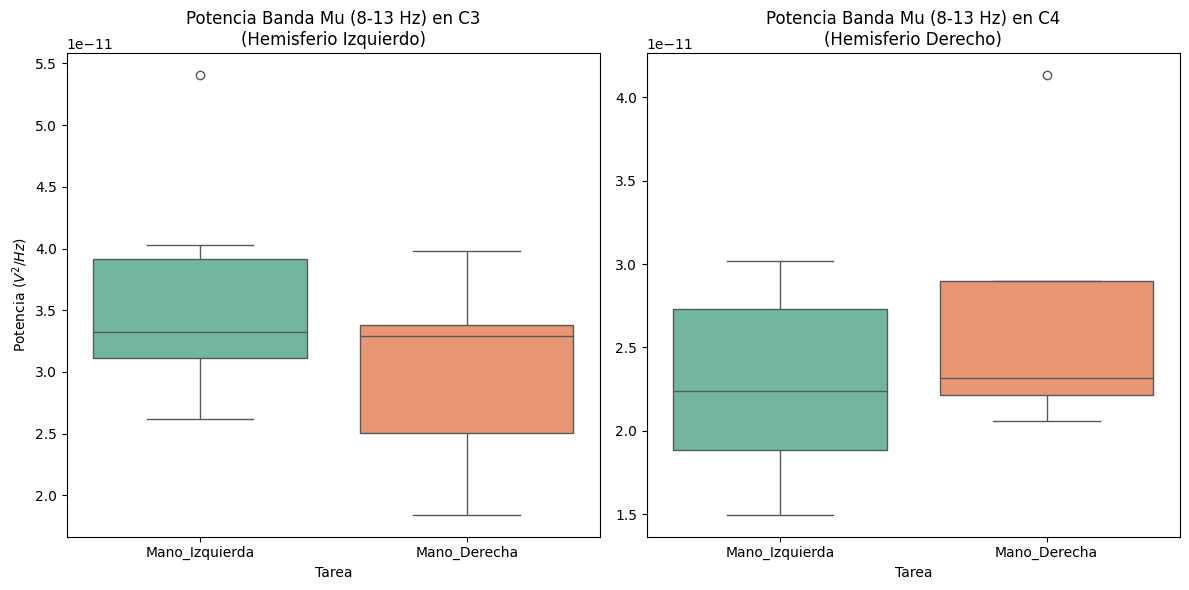

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ESTADÍSTICA DESCRIPTIVA (Gráficas Boxplot)
plt.figure(figsize=(12, 6))

# Boxplot para C3
plt.subplot(1, 2, 1)
sns.boxplot(x='Tarea', y='Potencia_Mu_C3', data=df_caracteristicas, palette='Set2')
plt.title('Potencia Banda Mu (8-13 Hz) en C3\n(Hemisferio Izquierdo)')
plt.ylabel('Potencia ($V^2/Hz$)')

# Boxplot para C4
plt.subplot(1, 2, 2)
sns.boxplot(x='Tarea', y='Potencia_Mu_C4', data=df_caracteristicas, palette='Set2')
plt.title('Potencia Banda Mu (8-13 Hz) en C4\n(Hemisferio Derecho)')
plt.ylabel('')

plt.tight_layout()
plt.show()



In [85]:
# PRUEBA DE NORMALIDAD (Shapiro-Wilk)
print("-" * 50)
print("PRUEBA DE NORMALIDAD (SHAPIRO-WILK) PARA CANAL C4")
print("-" * 50)

# Extraemos los datos numéricos para evaluarlos
datos_izq = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C4']
datos_der = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C4']

# Test de Shapiro-Wilk
stat_izq, p_izq = stats.shapiro(datos_izq)
stat_der, p_der = stats.shapiro(datos_der)

print(f"P-valor (Mano Izquierda): {p_izq:.5f}")
print(f"P-valor (Mano Derecha): {p_der:.5f}\n")

if p_izq > 0.05 and p_der > 0.05:
    print("CONCLUSIÓN: Los datos son NORMALES (p > 0.05).")
    print("Siguiente paso -> Aplicar T-Student (Paramétrica)")
else:
    print("CONCLUSIÓN: Los datos NO SON NORMALES (p <= 0.05).")
    print("Siguiente paso -> Aplicar U de Mann-Whitney (No Paramétrica)")

--------------------------------------------------
PRUEBA DE NORMALIDAD (SHAPIRO-WILK) PARA CANAL C4
--------------------------------------------------
P-valor (Mano Izquierda): 0.53450
P-valor (Mano Derecha): 0.05811

CONCLUSIÓN: Los datos son NORMALES (p > 0.05).
Siguiente paso -> Aplicar T-Student (Paramétrica)


In [86]:
from scipy import stats

# PRUEBA ESTADÍSTICA (T-STUDENT)

print("--- PRUEBA T DE STUDENT (Mano Izq vs Mano Der) ---\n")

# Extraemos los datos de la banda Mu para C3 y C4
mu_izq_C3 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C3']
mu_der_C3 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C3']

mu_izq_C4 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Izquierda']['Potencia_Mu_C4']
mu_der_C4 = df_caracteristicas[df_caracteristicas['Tarea'] == 'Mano_Derecha']['Potencia_Mu_C4']

# Aplicamos la prueba T de Student (muestras independientes) para C3
t_stat_c3, p_val_c3 = stats.ttest_ind(mu_izq_C3, mu_der_C3)

# Aplicamos la prueba T de Student para C4
t_stat_c4, p_val_c4 = stats.ttest_ind(mu_izq_C4, mu_der_C4)

#  Mostrar e interpretar resultados
print("Resultados en Canal C3 (Corteza Motora Izquierda):")
print(f"Estadístico T: {t_stat_c3:.4f} | P-valor: {p_val_c3:.5f}")
if p_val_c3 < 0.05:
    print("-> CONCLUSIÓN: Hay diferencia significativa en C3 (Se rechaza la Hipótesis Nula H0)\n")
else:
    print("-> CONCLUSIÓN: NO hay diferencia significativa en C3 (No se rechaza H0)\n")

print("Resultados en Canal C4 (Corteza Motora Derecha):")
print(f"Estadístico T: {t_stat_c4:.4f} | P-valor: {p_val_c4:.5f}")
if p_val_c4 < 0.05:
    print("-> CONCLUSIÓN: Hay diferencia significativa en C4 (Se rechaza la Hipótesis Nula H0)\n")
else:
    print("-> CONCLUSIÓN: NO hay diferencia significativa en C4 (No se rechaza H0)\n")

--- PRUEBA T DE STUDENT (Mano Izq vs Mano Der) ---

Resultados en Canal C3 (Corteza Motora Izquierda):
Estadístico T: 1.4611 | P-valor: 0.16774
-> CONCLUSIÓN: NO hay diferencia significativa en C3 (No se rechaza H0)

Resultados en Canal C4 (Corteza Motora Derecha):
Estadístico T: -1.1718 | P-valor: 0.26229
-> CONCLUSIÓN: NO hay diferencia significativa en C4 (No se rechaza H0)



## Referencias

[1]	A. Arjoonsingh, B. C. Jamal, and L. Ganti, “History and evolution of the electroencephalogram,” Cureus, vol. 16, no. 8, p. e66385, 2024. DOI: 10.7759/cureus.66385

[2] [Aplicaciones Reales de Interfaces Cerebro-Computadora](https://www.emotiv.com/es/blogs/news/brain-computer-interface-applications?srsltid=AfmBOoojTE66RzGV6x_orurA8rRNHyRrN4pjjo8hAX3lC5JDrejhn94o)

[3] [Brain-Computer Interfaces in Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3497935/)

[4] [The Berlin Brain–Computer Interface: Non-Medical Uses of BCI Technology](https://pmc.ncbi.nlm.nih.gov/articles/PMC3002462/)

[5] [EEG-based brain-computer interface enables real-time robotic hand control at individual finger level](https://www.nature.com/articles/s41467-025-61064-x)

Papers que nos pueden servir para el desarrollo del flujo y selección de las bandas 

- [An Empirical Model-Based Algorithm for Removing Motion-Caused Artifacts in Motor Imagery EEG Data for Classification Using an Optimized CNN Model](https://pubmed.ncbi.nlm.nih.gov/39686227/)
- [Cortical signals analysis to recognize intralimb mobility using modified RNN and various EEG quantities](https://pubmed.ncbi.nlm.nih.gov/38726180/)
- [Direction decoding of imagined hand movements using subject-specific features from parietal EEG](https://pubmed.ncbi.nlm.nih.gov/35901779/)
- [Decoding trajectories of imagined hand movement using electrocorticograms for brain-machine interface](https://pubmed.ncbi.nlm.nih.gov/35985293/)
- [Induced Gamma-Band Activity during Actual and Imaginary Movements: EEG Analysis](https://pubmed.ncbi.nlm.nih.gov/32168747/) Bandas de interés
- [Classifying EEG signals preceding right hand, left hand, tongue, and right foot movements and motor imageries](https://pubmed.ncbi.nlm.nih.gov/18845473/) De 2008
- [Mu-Beta event-related (de)synchronization and EEG classification of left-right foot dorsiflexion kinaesthetic motor imagery for BCI](https://pubmed.ncbi.nlm.nih.gov/32182270/)
- [Effect of brain-computer interface training based on non-invasive electroencephalography using motor imagery on functional recovery after stroke - a systematic review and meta-analysis](https://pubmed.ncbi.nlm.nih.gov/33092554/)
- [A Comprehensive Review on Critical Issues and Possible Solutions of Motor Imagery Based Electroencephalography Brain-Computer Interface](https://pubmed.ncbi.nlm.nih.gov/33804611/)
- [Classification of EEG signals recorded during right/left hand movement imagery using Fast Walsh Hadamard Transform based features](https://ieeexplore-ieee-org.udea.lookproxy.com/document/7760909) ¿Fast Walsh Hadamard Transform?

consulta -> resumen del proyecto en general


#### Filtros lineales 
La salida no se desfasa con respecto a  la entrada
- Filtros en frecuencia o en amplitud.

FIR e IIR son en recuencia.


### Filtros no lineales

Wavelet es en amplitud, lo descompone en aproximaciones y detalles 


Orden y frecuancia de corte son los parámetros más importates del filtro


RAW -> detrend -> Pasabanda -> FILTERED -> FFT welch -> PSD en las bandas de interés. Sumar la desidad de potencia espectral y se divide por la totalidad, eso me da la **potencia relativa** -> ahí se tiene en cuenta la tarea 

Buacar en la literatura el solapamiento de welch